In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from config import *

In [2]:
def fl_fig(df, chosen_metric, chosen_level):
    df_filtered = df[(df['metric'] == chosen_metric) & (df['level'] == chosen_level)]

    df_filtered = df_filtered.set_index('data_source').transpose()
    df_filtered = df_filtered.drop(['metric', 'level'])  # 불필요한 행 제거

    plt.figure(figsize=(10, 6))
    for data_source in df_filtered.columns:
        plt.plot(df_filtered.index, df_filtered[data_source], label=data_source)

    plt.title(f"Level: {chosen_level}, Metric: {chosen_metric}")
    plt.xlabel("Round")
    plt.ylabel(f"{chosen_metric}")
    plt.legend(title="Data Source")
    plt.grid(True)
    plt.show()

In [11]:
lvs = range(1,5)
fl_rounds = range(1,30)

# Condition 1

In [12]:
condition = 1
total_results = []
for lv in lvs:
    lv_results = []
    for dat_src in DATA_SOURCE:
        source_result_df = pd.DataFrame()
        for fl_round in fl_rounds:
            result_temp = pd.read_csv(RESULT_PATH + f"Condition{condition}/lv{lv}/round{fl_round}/{dat_src}_results.csv", index_col = 0)
            source_result_df = pd.concat([source_result_df, result_temp.iloc[2,:]], axis =1)
        source_result_df.columns = fl_rounds
        source_result_df['data_source'] = dat_src
        source_result_df.reset_index(inplace = True)
        source_result_df = source_result_df.rename(columns = {'index':'metric'})
        lv_results.append(source_result_df)
    temp_lv_result = pd.concat(lv_results, axis = 0)
    temp_lv_result['level'] = lv
    total_results.append(temp_lv_result)

In [13]:
total_result_df = pd.concat(total_results, axis = 0)

In [14]:
df = total_result_df

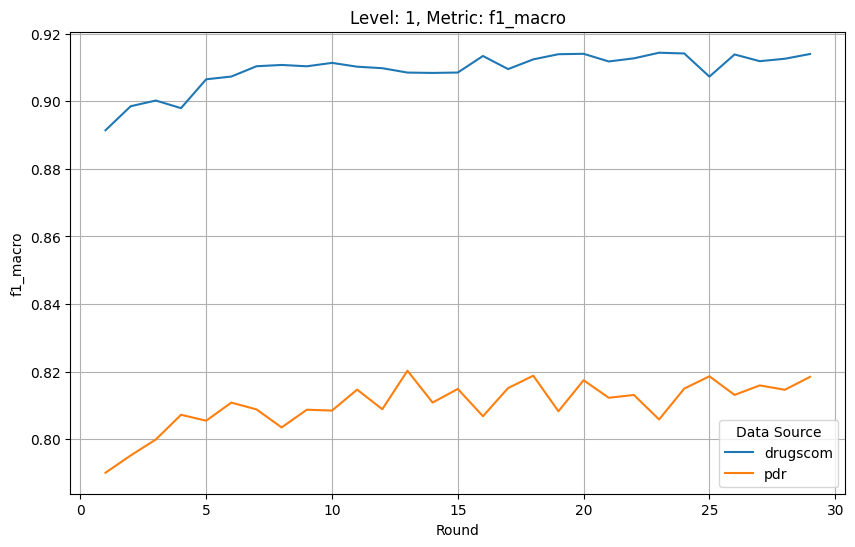

In [15]:
fl_fig(df, 'f1_macro', 1)

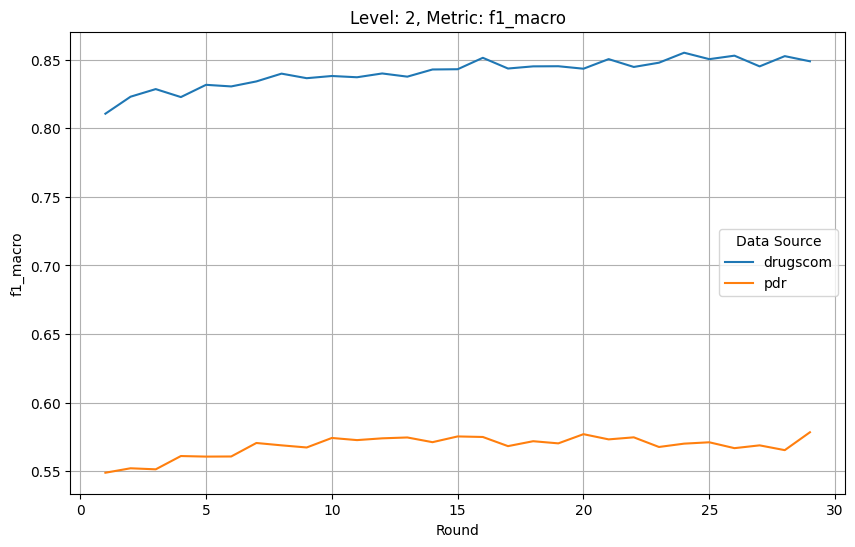

In [16]:
fl_fig(df, 'f1_macro', 2)

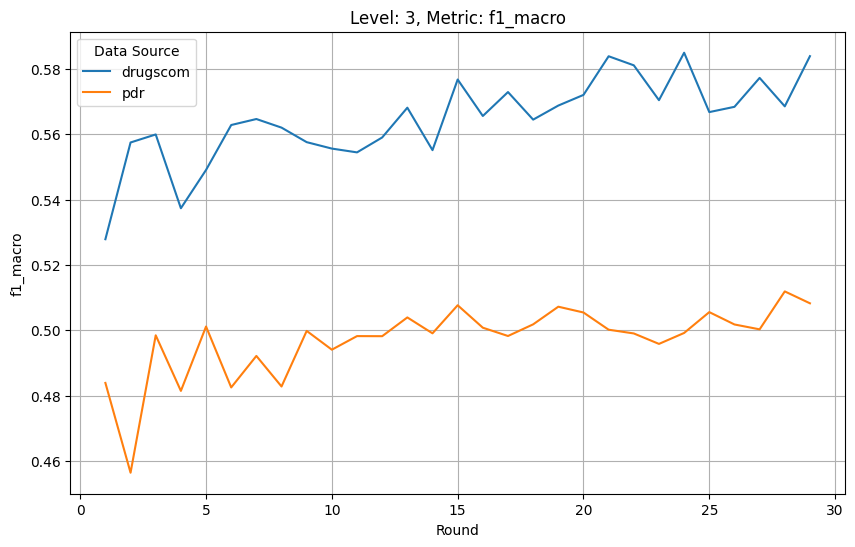

In [17]:
fl_fig(df, 'f1_macro', 3)

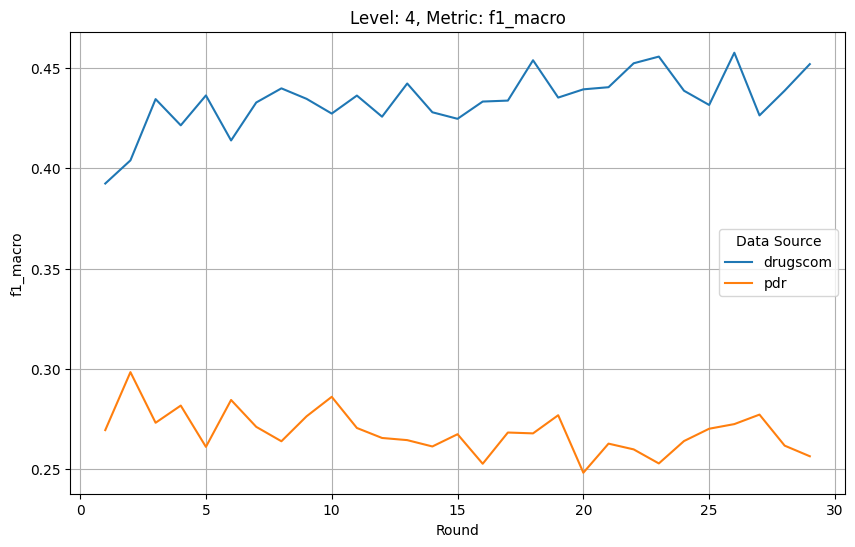

In [18]:
fl_fig(df, 'f1_macro', 4)

# Condition 2

In [27]:
condition = 2
total_results = []
for lv in lvs:
    lv_results = []
    for dat_src in DATA_SOURCE:
        source_result_df = pd.DataFrame()
        for fl_round in fl_rounds:
            result_temp = pd.read_csv(RESULT_PATH + f"Condition{condition}/lv{lv}/round{fl_round}/{dat_src}_results.csv", index_col = 0)
            source_result_df = pd.concat([source_result_df, result_temp.iloc[2,:]], axis =1)
        source_result_df.columns = fl_rounds
        source_result_df['data_source'] = dat_src
        source_result_df.reset_index(inplace = True)
        source_result_df = source_result_df.rename(columns = {'index':'metric'})
        lv_results.append(source_result_df)
    temp_lv_result = pd.concat(lv_results, axis = 0)
    temp_lv_result['level'] = lv
    total_results.append(temp_lv_result)

In [28]:
total_result_df = pd.concat(total_results, axis = 0)

In [29]:
df2 = total_result_df

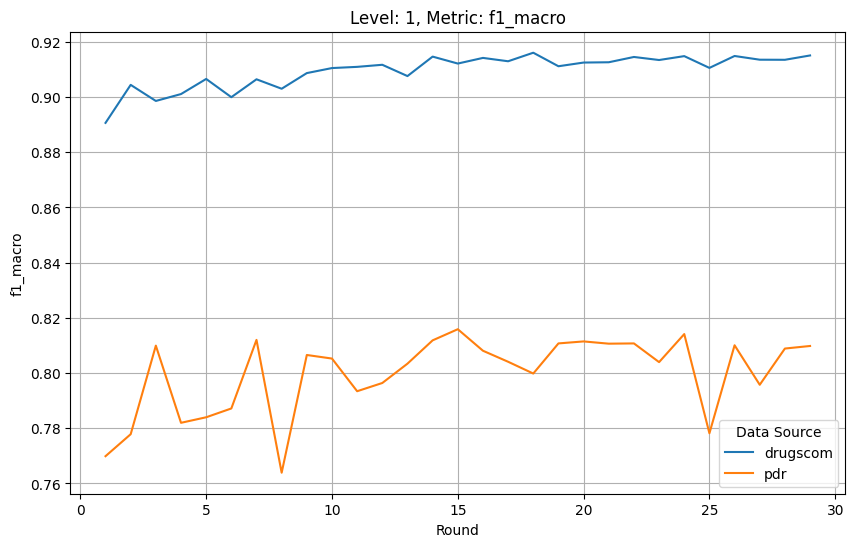

In [30]:
fl_fig(df2, 'f1_macro', 1)

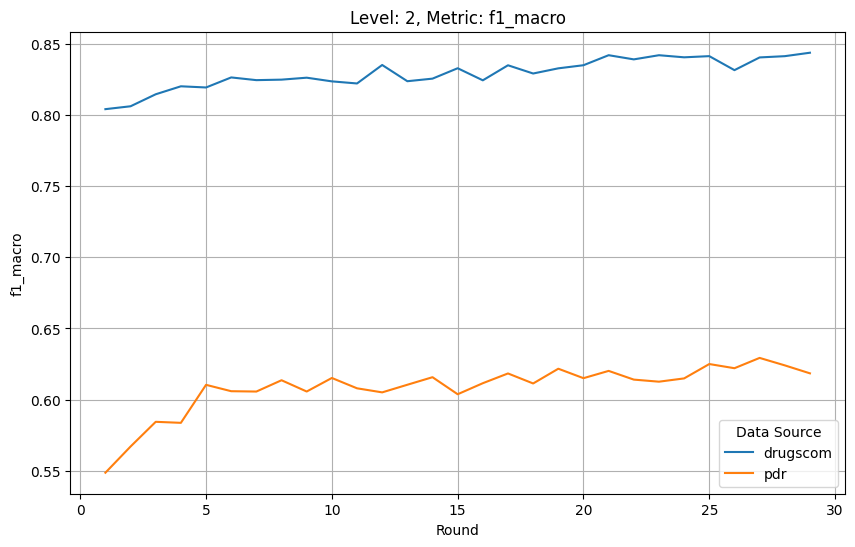

In [31]:
fl_fig(df2, 'f1_macro', 2)

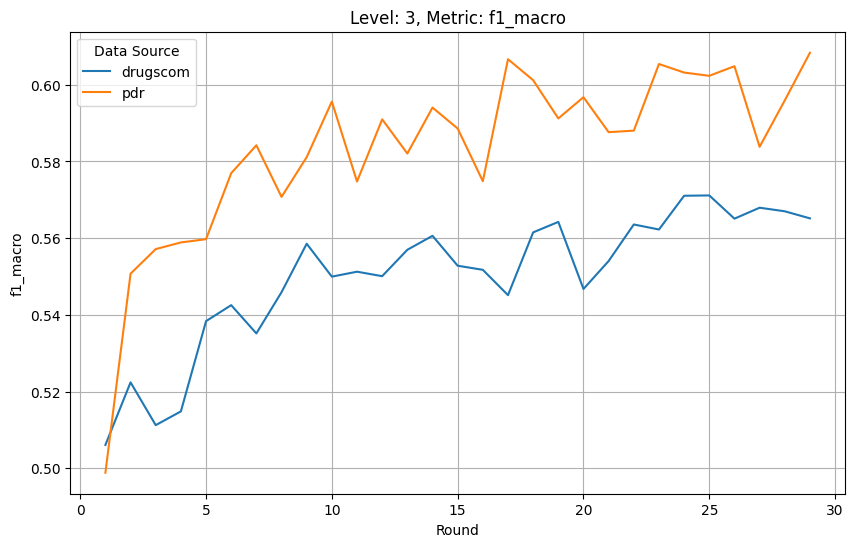

In [32]:
fl_fig(df2, 'f1_macro', 3)

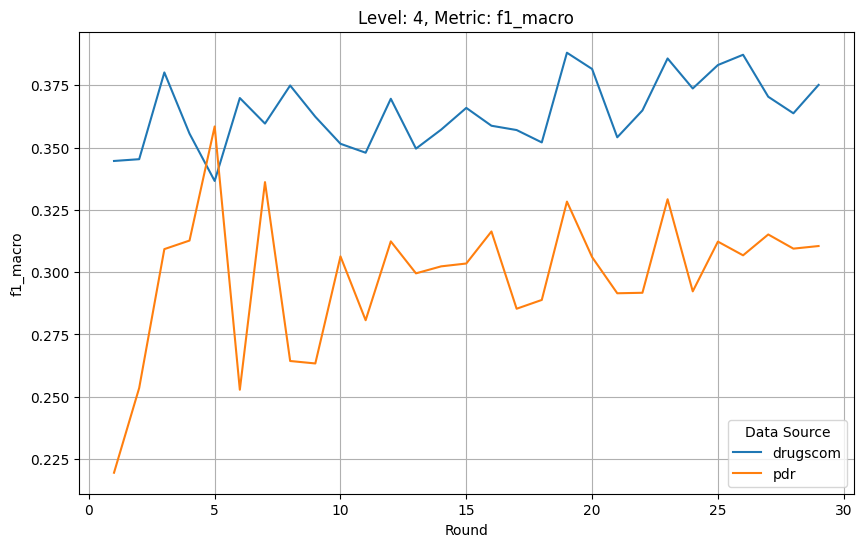

In [33]:
fl_fig(df2, 'f1_macro', 4)

## Check effect

In [76]:
chosen_metric = 'f1_macro'
chosen_dat_src = 'drn'

In [77]:
import seaborn as sns

def effect_plot_cond(data, chosen_metric, chosen_dat_src):
    filtered_data = data[(data['metric'] == chosen_metric) & (data['data_source'] == chosen_dat_src)]
    dat_src_dict = {'drn':'Dr.Noah','drugscom':'Drugs.com','pdr':'pdr'}
    # 바 플롯 생성
    plt.figure(figsize=(10, 6))
    barplot = sns.barplot(data=filtered_data, x='level', y='effect', hue='condition')#, ci=None)
    
    # 제목과 라벨 설정
    plt.title(f"[{dat_src_dict[chosen_dat_src]}] Effect of Federated Learning by Condition for Each Level")
    plt.xlabel("Level")
    plt.ylabel(f"Delta {chosen_metric}")

    plt.legend(title="Condition")
    plt.show()
    
def effect_plot_dat_src(data, chosen_metric, chosen_cond):
    filtered_data = data[(data['metric'] == chosen_metric) & (data['condition'] == chosen_cond)]
    dat_src_dict = {'drn':'Dr.Noah','drugscom':'Drugs.com','pdr':'pdr'}
    # 바 플롯 생성
    plt.figure(figsize=(10, 6))
    sns.barplot(data=filtered_data, x='level', y='effect', hue='data_source')#, ci=None)
    
    # 제목과 라벨 설정
    plt.title(f"[{chosen_cond}] Effect of Federated Learning by Data Source for Each Level")
    plt.xlabel("Level")
    plt.ylabel(f"Delta {chosen_metric}")

    plt.legend(title="Data Source")
    plt.show()

In [78]:
eff = df.loc[:,11] - df.loc[:,1]
eff2 = df2.loc[:,11] - df2.loc[:,1]

eff_df = pd.DataFrame({'effect':eff, 'metric':df.metric, 'data_source':df.data_source, 'level':df.level})
eff_df['condition'] = 'condition_1'

eff_df2 = pd.DataFrame({'effect':eff2, 'metric':df2.metric, 'data_source':df2.data_source, 'level':df2.level})
eff_df2['condition'] = 'condition_2'

data = pd.concat([eff_df, eff_df2],axis = 0)

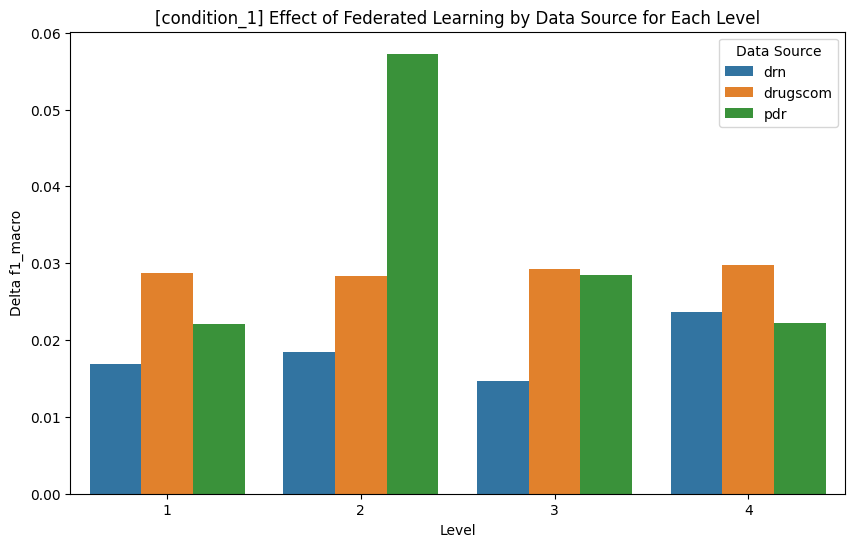

In [79]:
effect_plot_dat_src(data, 'f1_macro', 'condition_1')

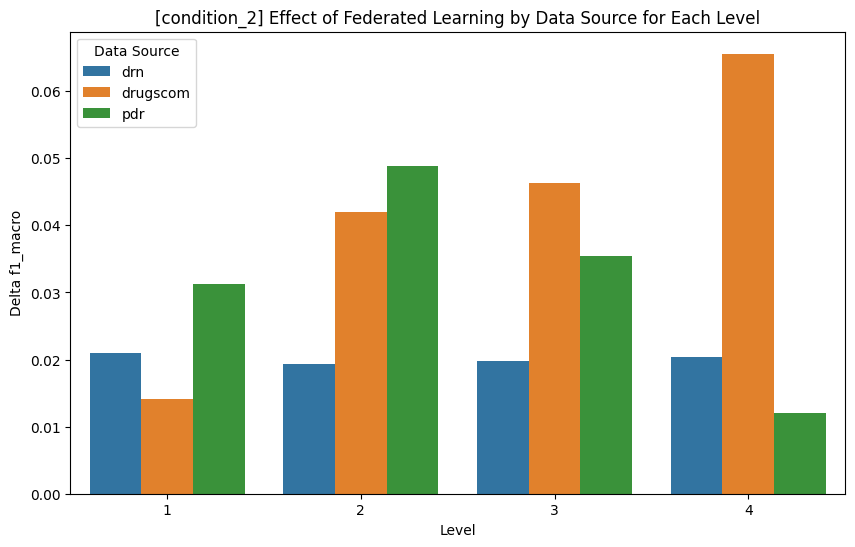

In [80]:
effect_plot_dat_src(data, 'f1_macro', 'condition_2')

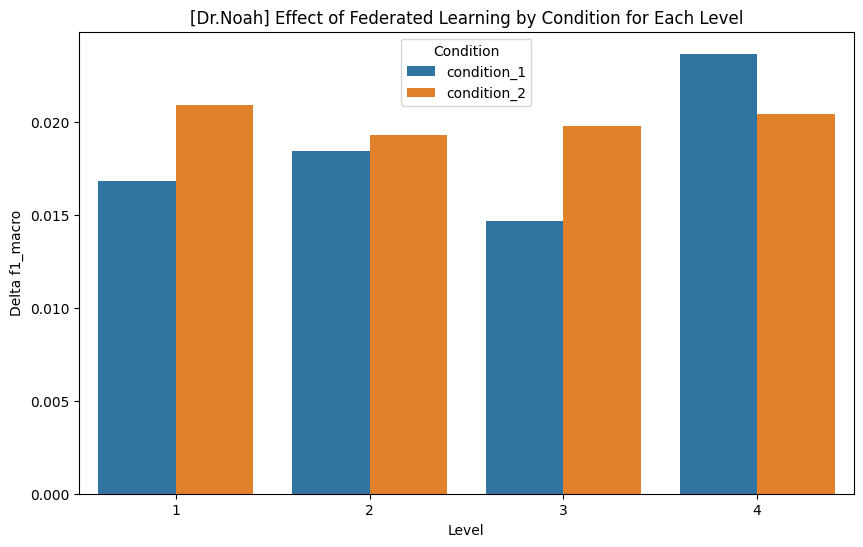

In [81]:
effect_plot_cond(data, 'f1_macro', 'drn')

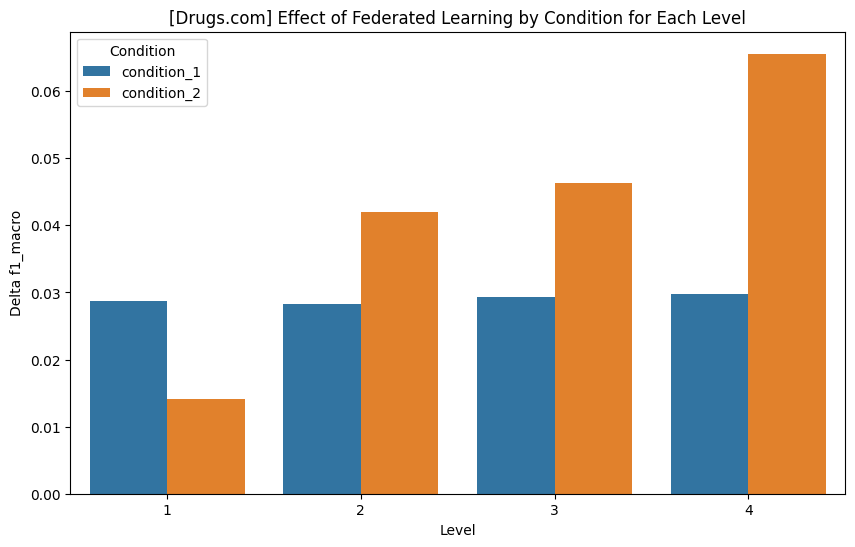

In [82]:
effect_plot_cond(data, 'f1_macro', 'drugscom')

In [ ]:
effect_plot_cond(data, 'f1_macro', 'pdr')